In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

(720, 720, 3)


True

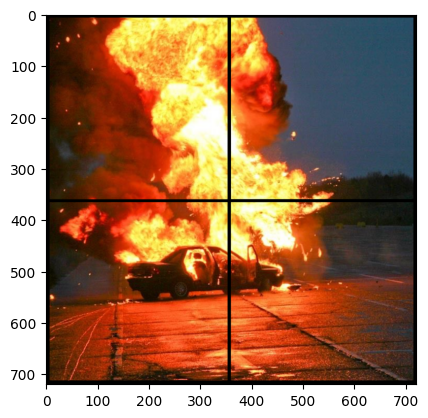

In [78]:
meleda = cv.imread('Assets/Meledak.png')
meledak = cv.cvtColor(meleda, cv.COLOR_BGR2RGB)

plt.imshow(meledak)

print(meledak.shape)

cv.imwrite('p.jpg', meledak)

In [91]:
def potong(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

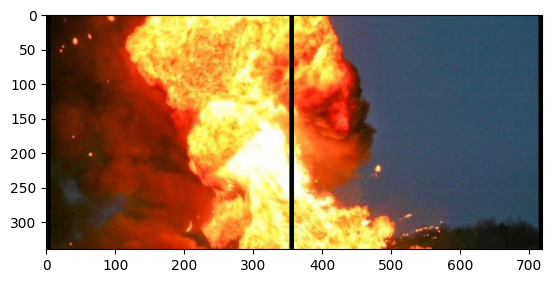

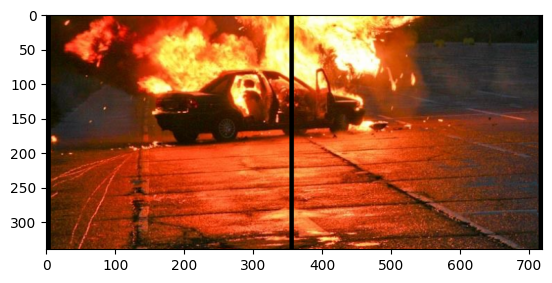

In [96]:
meledakAtas = potong(meledak, 10, 350, mode='H')
meledakBawah = potong(meledak, 370, 710, mode = 'H')

plt.imshow(meledakAtas, cmap = 'gray')
plt.show()

plt.imshow(meledakBawah, cmap = 'gray')
plt.show()

Text(0.5, 1.0, 'Citra 4')

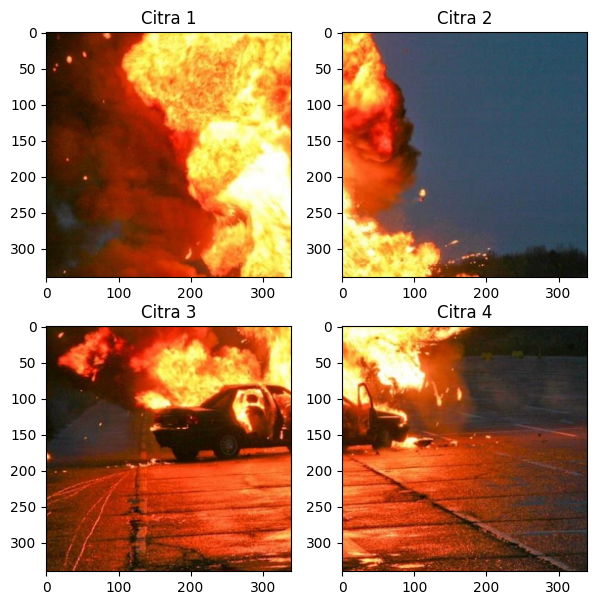

In [98]:
meledakAtas_v1 = potong(meledakAtas, 10, 350, mode='V')
meledakAtas_v2 = potong(meledakAtas, 370, 710, mode='V')
meledakBawah_v1 = potong(meledakBawah, 10, 350, mode='V')
meledakBawah_v2 = potong(meledakBawah, 370, 710, mode='V')

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow(meledakAtas_v1, cmap = 'gray')
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(meledakAtas_v2, cmap = 'gray')
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(meledakBawah_v1, cmap = 'gray')
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(meledakBawah_v2, cmap = 'gray')
plt.title('Citra 4')


In [ ]:
def merge(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

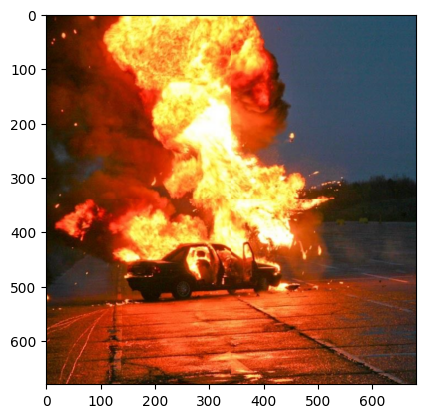

In [107]:
meledakMAtas = merge(meledakAtas_v1, meledakAtas_v2, orientation='H')
meledakMBawah = merge(meledakBawah_v1, meledakBawah_v2, orientation='H')
meledakM = merge(meledakMAtas, meledakMBawah, orientation='V')

plt.imshow(meledakM)

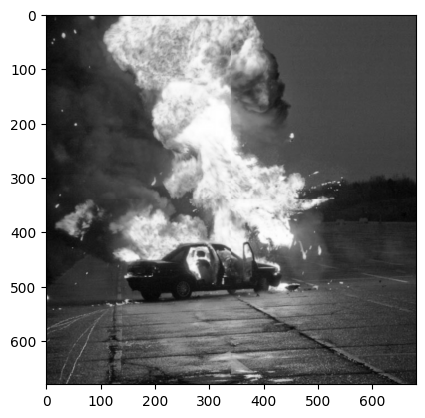

In [111]:
meledakG = cv.cvtColor(meledakM, cv.COLOR_RGB2GRAY)

plt.imshow(meledakG, cmap = 'gray')

In [168]:
def ekualisasi(citra): 
    height, width = citra.shape 
 
    hist = np.zeros(256, dtype=int) 
 
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0] 
 
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8) 
 
    hasil = np.zeros_like(citra, dtype=np.uint8) 

    return 

def histogram_equalization(image):
    e_hist = np.zeros(256, dtype=int)
    height, width = image.shape

    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            e_hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(e_hist[0:i+1])

    result = np.round((cdf * 255) / (height * width)).astype(np.uint8)

    result2 = np.zeros(image.shape, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            result2[i, j] = result[val]

    return result2

def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show()

In [ ]:
meledakH = buat_hist(meledakG)
meledakE = histogram_equalization(meledakG)
meledakEH = buat_hist(meledakE)

histH = plot_histogram(meledakH, 'p', 'green')
histEH = plot_histogram(meledakEH, 'Hai', 'red')


IndexError: invalid index to scalar variable.

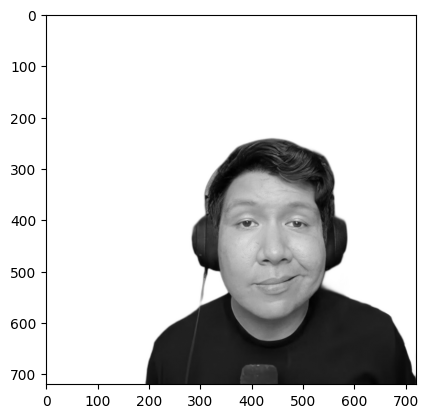

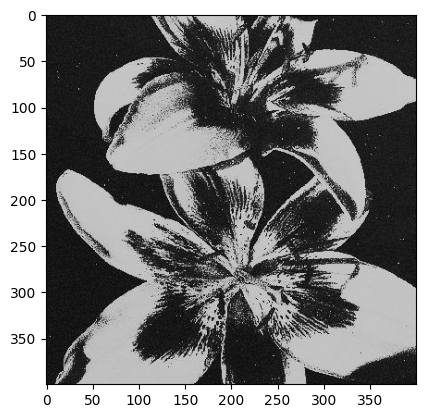

In [148]:
windut = cv.imread('Assets/Windut.png')
windutG = cv.cvtColor(windut, cv.COLOR_BGR2GRAY)
bireng = cv.imread('Assets/Bunga.png')

plt.imshow(windutG, cmap = 'gray')
plt.show()

plt.imshow(bireng)
plt.show()

In [161]:
def histogram_specification(source, target):
    height, width = source.shape

    # Hitung histogram source
    hist_source = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist_source[source[i, j]] += 1
    cdf_source = np.cumsum(hist_source)
    cdf_source = np.round(cdf_source * 255 / cdf_source[-1]).astype(np.uint8)

    # Hitung histogram target
    hist_target = np.zeros(256, dtype=int)
    for i in range(target.shape[0]):
        for j in range(target.shape[1]):
            hist_target[target[i, j]] += 1
    cdf_target = np.cumsum(hist_target)
    cdf_target = np.round(cdf_target * 255 / cdf_target[-1]).astype(np.uint8)

    # Buat mapping dari CDF source ke CDF target
    mapping = np.zeros(256, dtype=np.uint8)
    for source_val in range(256):
        diff = np.abs(cdf_source[source_val] - cdf_target)
        mapping[source_val] = np.argmin(diff)

    # Terapkan mapping ke gambar source
    result = np.zeros_like(source)
    for i in range(height):
        for j in range(width):
            result[i, j] = mapping[source[i, j]]

    return result

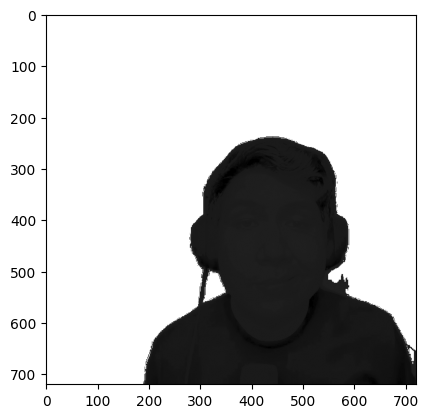

In [165]:
Wspek = histogram_specification(windutG, bireng)

plt.imshow(Wspek, cmap = 'gray')

In [ ]:
def tampilkan_histogram(citra, warna = "black"):
    histogram = np.zeros(256, dtype=int)

    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            nilai = int(citra[i, j])
            histogram[nilai] += 1
            
    plt.bar(range(256), histogram, width = 1, color = warna)
    plt.grid(True)

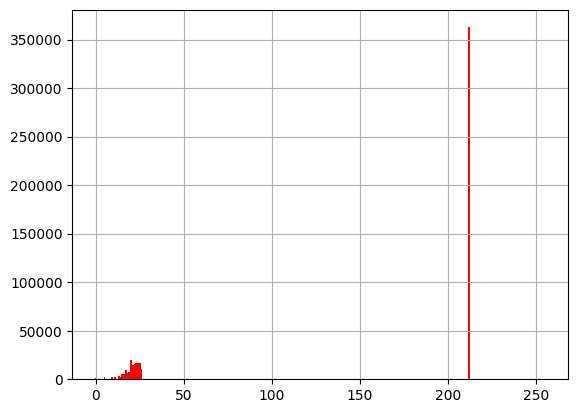

In [167]:
histWS = tampilkan_histogram(Wspek, 'red')